<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/exercices_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Agregando Librerias

In [ ]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0b346fb1c8b632656d63e6d6d32ae2d8468cf76aa645a86bb282051572dab2f1
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.ensemble import RandomForestRegressor
import sklearn.model_selection as skm

Vamos a desarrollar la parte practica

# 7

In [ ]:
boston = load_data("Boston")

In [ ]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


En este dataset, tenemos que aplicar Random Forest con determinadas configuraciones, la variable respuesta es *medv*

In [ ]:
# vamos a hacer los primeros seteos con el modelo
model = MS(boston.columns.drop("medv"))
D = model.fit_transform(boston)

feature_names = list(D.columns)

X = np.asarray(D)


In [ ]:
X_train, X_test, y_train, y_test = skm.train_test_split(X,
                                                        boston['medv'],
                                                        test_size=.3,
                                                        random_state=42)

In [ ]:
boston_rf = RandomForestRegressor(max_features=6, n_estimators=100).fit(X_train, y_train)
y_hat_rf = boston_rf.predict(X_test)
np.mean((y_test - y_hat_rf)**2)


np.float64(9.68399655921053)

Necesitamos hacer un grafico en el que mostramos la evoluacion del MSE respecto de variaciones en los parametros. Especificamente la cantidad de features y los n_estimators.

In [31]:
# haremos un gridsearch
params = {"n_estimators": [50, 100, 200 ,300 ,400 , 500],
          "max_features": np.arange(1, X_train.shape[1], 2)}

boston_rf = RandomForestRegressor(max_features=6,
                                  n_estimators=100,
                                  random_state=42)
kfold = skm.KFold(5,
                  random_state=42,
                  shuffle=True)
grid = skm.GridSearchCV(boston_rf,
                        param_grid=params,
                        scoring="neg_mean_squared_error",
                        n_jobs=-1,
                        verbose=2)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)





Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_features': np.int64(5), 'n_estimators': 50}
-12.867244527806843


In [32]:
results = pd.DataFrame(grid.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.147545,0.013876,0.011213,0.000524,1,50,"{'max_features': 1, 'n_estimators': 50}",-18.600030,-18.579454,-26.931981,-12.937813,-22.010979,-19.812051,4.599394,36
1,0.267375,0.005234,0.018335,0.000077,1,100,"{'max_features': 1, 'n_estimators': 100}",-15.901557,-16.530594,-25.377569,-11.995456,-21.295476,-18.220130,4.640336,35
2,0.562506,0.009543,0.038322,0.003717,1,200,"{'max_features': 1, 'n_estimators': 200}",-15.466094,-15.599550,-25.593289,-11.865030,-21.027403,-17.910273,4.829154,32
3,0.832740,0.013429,0.052416,0.001483,1,300,"{'max_features': 1, 'n_estimators': 300}",-15.894542,-15.077325,-26.096178,-12.512424,-21.110799,-18.138254,4.862470,34
4,1.275567,0.292233,0.084977,0.024162,1,400,"{'max_features': 1, 'n_estimators': 400}",-15.608374,-14.947483,-26.062199,-12.644868,-20.963633,-18.045311,4.847413,33


In [33]:
results = results[["param_max_features", "param_n_estimators", "mean_test_score"]]
results.head()

,param_max_features,param_n_estimators,mean_test_score
0,1,50,-19.812051
1,1,100,-18.220130
2,1,200,-17.910273
3,1,300,-18.138254
4,1,400,-18.045311


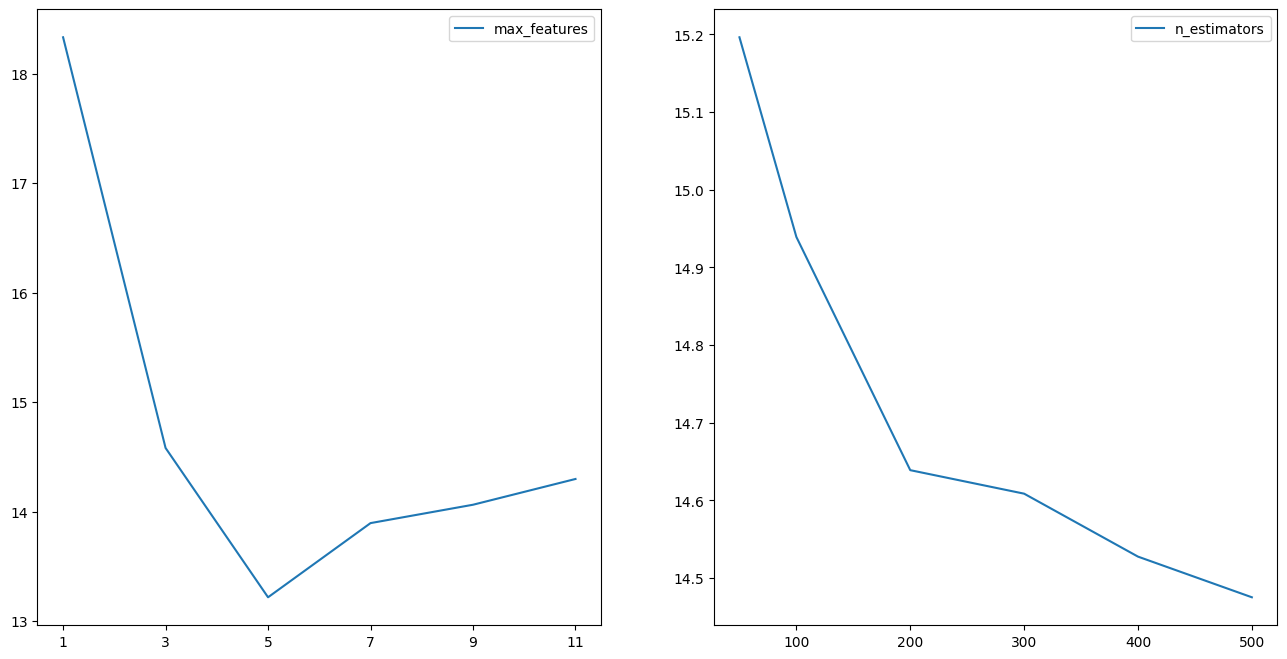

In [34]:
# vamos a graficar
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
data_features = results.groupby("param_max_features").mean()
ax[0].plot([str(i) for i in data_features.index], -data_features["mean_test_score"], label="max_features")
ax[0].legend()
data_estimators = results.groupby("param_n_estimators")["mean_test_score"].mean()
ax[1].plot(data_estimators.index, -data_estimators, label="n_estimators")
ax[1].legend()
plt.show()

In [ ]:
data_estimators = results.groupby("param_n_estimators")["mean_test_score"].mean()
data_estimators

,mean_test_score
param_n_estimators,
50,-15.112885
100,-14.720715
200,-14.431915
300,-14.341900
400,-14.254070
500,-14.220134


In [36]:
test_m_features = {}
max_n_estimators = 250

for max_feature in range(1, X_train.shape[1] + 1):
    test_m_features[max_feature] = []

    rf = RandomForestRegressor(n_estimators=1,
                               max_features=max_feature,
                               warm_start=True,
                               random_state=42)

    for estimator in range(1, max_n_estimators + 1):
        rf.n_estimators = estimator

        rf.fit(X_train, y_train)

        error = np.mean((y_test - rf.predict(X_test))**2)
        test_m_features[max_feature].append(error)

print("¡Terminado mucho más rápido!")

¡Terminado mucho más rápido!


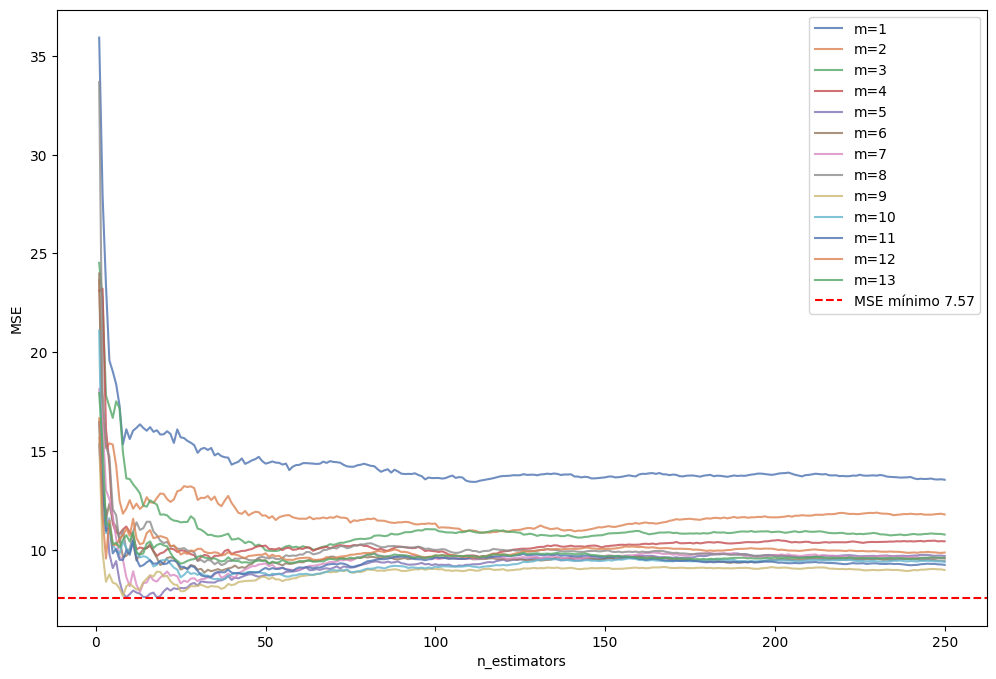

In [42]:
# ahora vamos a graficar
fig, ax = plt.subplots(figsize=(12,8))
palette = sns.color_palette("deep", len(test_m_features))

for key, value in test_m_features.items():
  sns.lineplot(x=np.arange(1, max_n_estimators + 1),
               y=value,
               label=f"m={key}",
               ax=ax,
               color=palette[key - 1],
               alpha=0.8)
min_mse = min([min(value) for value in test_m_features.values()])
ax.axhline(y=min_mse,
           color="red",
           linestyle="--",
           label=f"MSE mínimo {min_mse.round(2)}")
ax.legend()
ax.set_xlabel("n_estimators")
ax.set_ylabel("MSE")
plt.show()

Podemos apreciar que en la busqueda, el cambio de max_features hasta un valor de 5 representa una gran caida en el mse del modelo. El valor minimo de MSE obtenido fue con la configuracion de 5 como max_features y 25 de n_estimators.

# 8

In [ ]:
#